![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [1]:

#!sudo apt-get install libgomp1
#!sudo apt-get install libxft2
#!sudo apt-get install libglu1

Run everytime you start to execute this Jupyter Notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength

### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

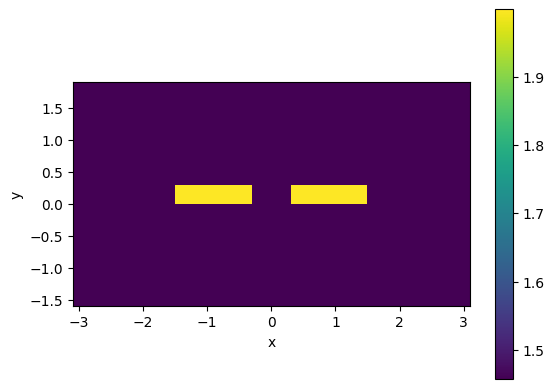

In [4]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()


### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [5]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-05-01 23:04:33.342 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_cbc1bb971a882eda.npz.
[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [6]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [7]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

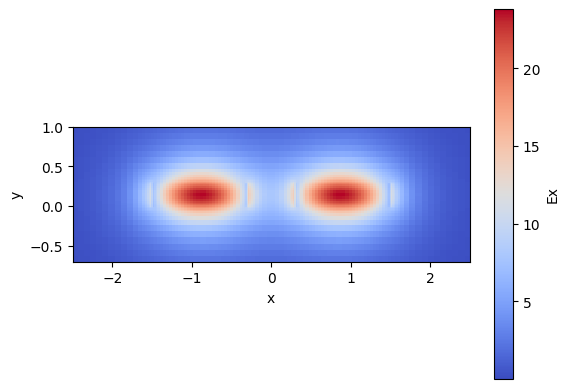

In [8]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) 

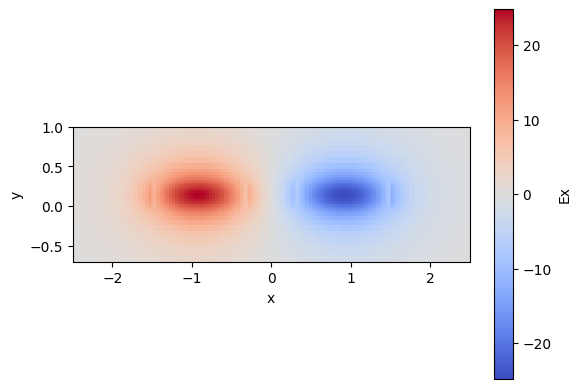

In [9]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

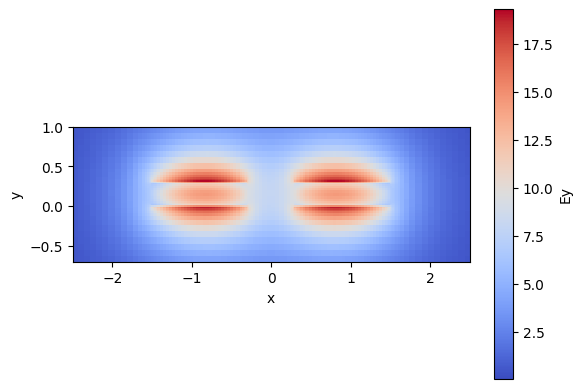

In [10]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

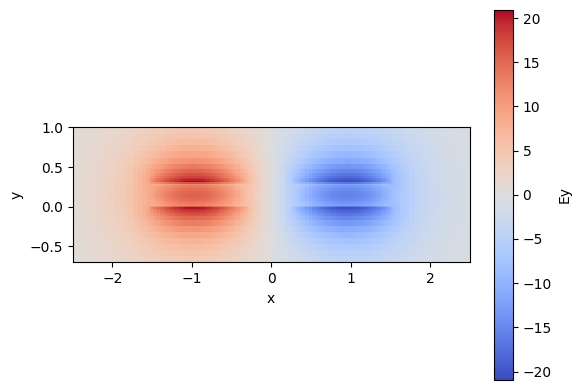

In [11]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [12]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536697725
52.2602236774508


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [13]:
dcoupler_cs.coupling_length()

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

L_pi_TE: 90.81065358094573
L_pi_TM 50.57441001043626


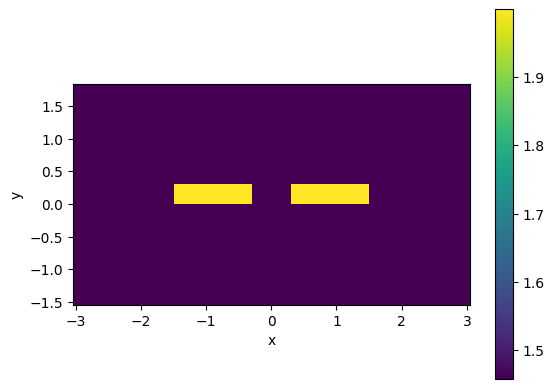

In [14]:
lambda_c = 1.5

L=np.linspace(1,180,30)
KTM=[]
KTE=[]

wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,

    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material

    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print("L_pi_TE:",L_pi_TE)

# TM Modes: Modes 2 & 3
L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print("L_pi_TM", L_pi_TM)


/tmp/ipykernel_1044/1733277194.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


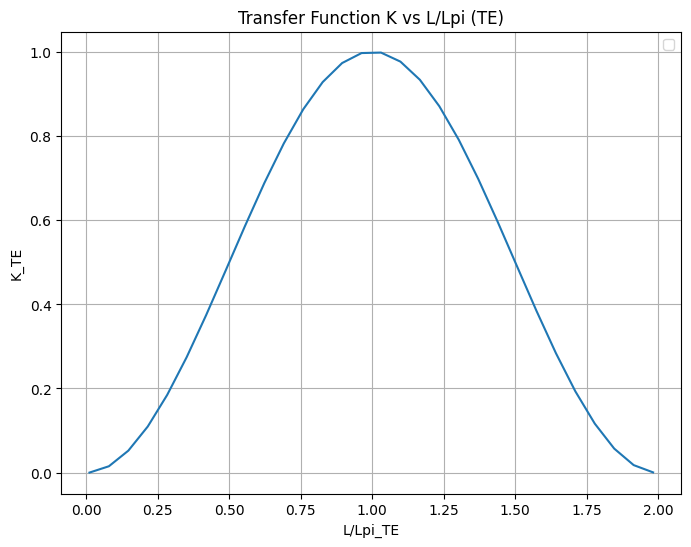

/tmp/ipykernel_1044/1733277194.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


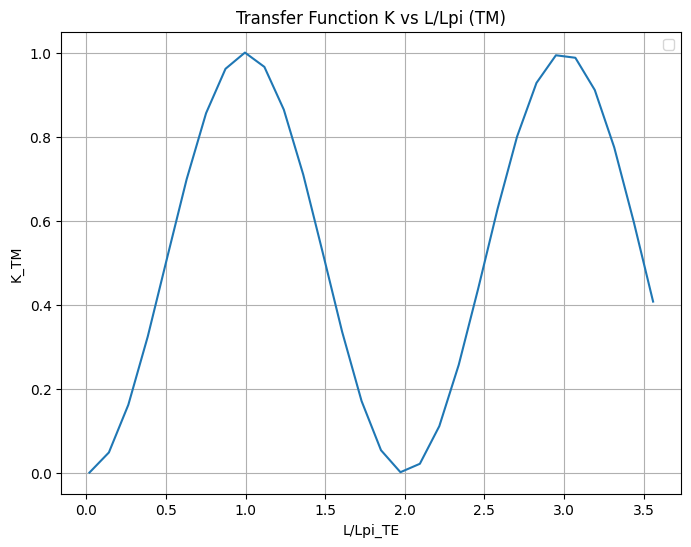

In [15]:
L = np.linspace(1,180, 30)
K_TE = np.sin(0.5 * np.pi * (L / L_pi_TE))**2
K_TM = np.sin(0.5 * np.pi * (L / L_pi_TM))**2

plt.figure(figsize=(8, 6))
plt.plot(L/L_pi_TE, K_TE)
plt.title("Transfer Function K vs L/Lpi (TE)")
plt.xlabel("L/Lpi_TE")
plt.ylabel("K_TE")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(L/L_pi_TM, K_TM)
plt.title("Transfer Function K vs L/Lpi (TM)")
plt.xlabel("L/Lpi_TE")
plt.ylabel("K_TM")
plt.grid(True)
plt.legend()
plt.show()

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [15]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 1.2
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2
m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
# the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -580.4293623083195  µm


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2147
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8916
Total OUT power: 0.8818
Excess loss [dB] =  0.5464
------------------------
Power over OUTs:  ['0.4407', '0.4410']
Ratio over OUTs ['0.4998', '0.5002']


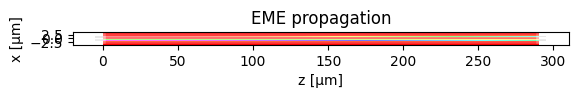

In [18]:
# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



2026-05-01 23:29:40.078 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_87641d4cdc9dd751.npz.
2026-05-01 23:29:40.115 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_804e6ebd40f61ba8.npz.
2026-05-01 23:29:40.137 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_61e4bf0dadb608a7.npz.
2026-05-01 23:29:40.156 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_4d1e2e3fed46470a.npz.
2026-05-01 23:29:40.174 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d1aed131e31ddaa8.npz.
2026-05-01 23:29:40.200 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_3289ee37612d8261.npz.


2026-05-01 23:29:40.217 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_0b1e3a643ef9a0ff.npz.
2026-05-01 23:29:40.235 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_bbd13b631f6a27a3.npz.
2026-05-01 23:29:40.254 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_492b618ed513eabe.npz.
2026-05-01 23:29:40.273 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_00c32396934056f4.npz.
2026-05-01 23:29:40.295 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_e20b841fd285fb81.npz.
2026-05-01 23:29:40.314 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_097ad0b6b193c64c.npz.
2026-05-01 23:29:40.334 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_26ba4a3be1b36ed7.npz.
2026-05-01 23:29:40.352 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

23:31:09 CEST WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-05-01 23:31:09.240 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_9362e2a8d21d6c58.npz.


...

2026-05-01 23:40:23.932 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_517f55bbf2ee09fe.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

2026-05-01 23:40:41.361 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_1adb868b12198c3d.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

2026-05-01 23:41:04.105 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_9cc87f71f661cbca.npz.
Deep etch -> gap mínimo ≈ 3.85 um
Shallow etch -> gap mínimo ≈ 4.95 um


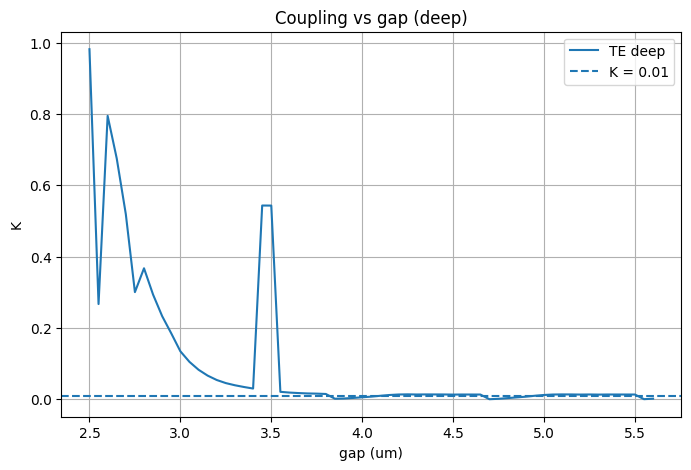

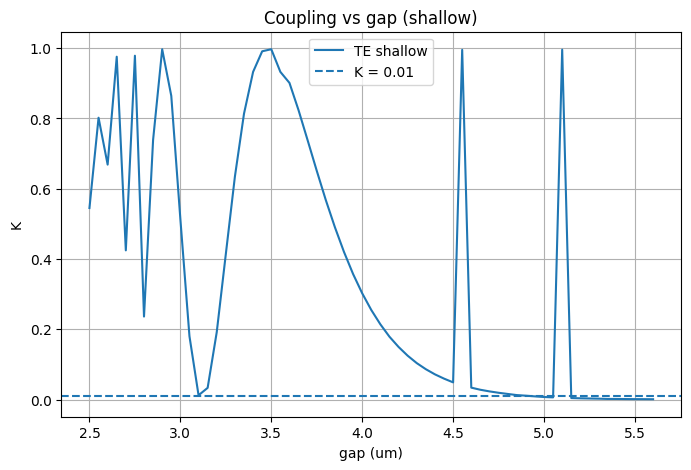

In [16]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 
 
import numpy as np
import matplotlib.pyplot as plt
 
lambda0 = 1.55       # um
wg_width = 1.0       # um
L = 10_000           # um = 10 mm
K_limit = 0.01
 
gaps = np.arange(2.5, 5.61, 0.05)   
 
K_TE_deep = []
K_TE_shallow = []
 
for gap in gaps:
    # DEEP etch
    dc_deep = gt.modes.WaveguideCoupler(
        wavelength=lambda0,
        core_width=(wg_width, wg_width),
        gap=gap,
        slab_thickness=0.0,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )
 
    neff_deep = dc_deep.n_eff
    Lpi_deep = lambda0 / (2 * np.abs(neff_deep[0].real - neff_deep[1].real))
    K_deep = np.sin(np.pi * L / (2 * Lpi_deep))**2
    K_TE_deep.append(K_deep)
 
    # SHALLOW etch
    dc_shallow = gt.modes.WaveguideCoupler(
        wavelength=lambda0,
        core_width=(wg_width, wg_width),
        gap=gap,
        slab_thickness=150 * nm,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )
 
    neff_shallow = dc_shallow.n_eff
    Lpi_shallow = lambda0 / (2 * np.abs(neff_shallow[0].real - neff_shallow[1].real))
    K_shallow = np.sin(np.pi * L / (2 * Lpi_shallow))**2
    K_TE_shallow.append(K_shallow)
 
K_TE_deep = np.array(K_TE_deep)
K_TE_shallow = np.array(K_TE_shallow)
 
# minimum gap
idx_deep = np.where(K_TE_deep < K_limit)[0]
idx_shallow = np.where(K_TE_shallow < K_limit)[0]
 
if len(idx_deep) > 0:
    print(f"Deep etch -> gap mínimo ≈ {gaps[idx_deep[0]]:.2f} um")
else:
    print("Deep etch -> no encontrado en el rango barrido")
 
if len(idx_shallow) > 0:
    print(f"Shallow etch -> gap mínimo ≈ {gaps[idx_shallow[0]]:.2f} um")
else:
    print("Shallow etch -> no encontrado en el rango barrido")
 
# plot TE deep
plt.figure(figsize=(8,5))
plt.plot(gaps, K_TE_deep, label='TE deep')
plt.axhline(K_limit, linestyle='--', label='K = 0.01')
 
plt.xlabel('gap (um)')
plt.ylabel('K')
plt.title('Coupling vs gap (deep)')
plt.grid(True)
plt.legend()
plt.show()

# plot TE shallow
plt.figure(figsize=(8,5))
plt.plot(gaps, K_TE_shallow, label='TE shallow')
plt.axhline(K_limit, linestyle='--', label='K = 0.01')
 
plt.xlabel('gap (um)')
plt.ylabel('K')
plt.title('Coupling vs gap (shallow)')
plt.grid(True)
plt.legend()
plt.show()

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [18]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

2026-05-01 23:46:11.547 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [19]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

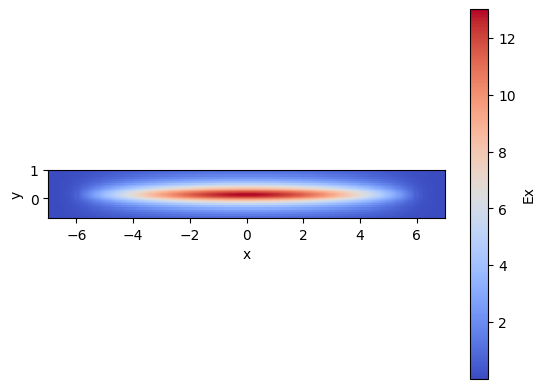

In [20]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

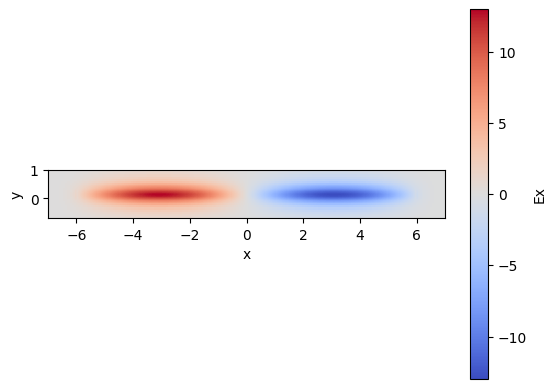

In [21]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

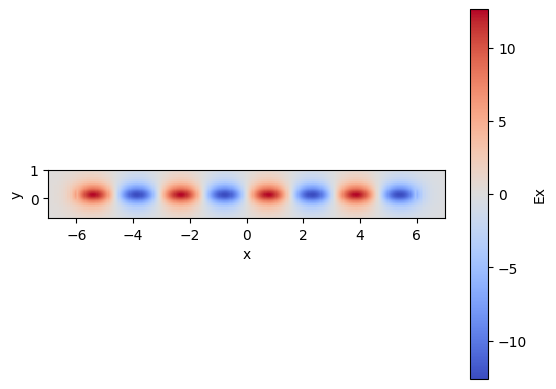

In [22]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [23]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794412975


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [24]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607256414  µm


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


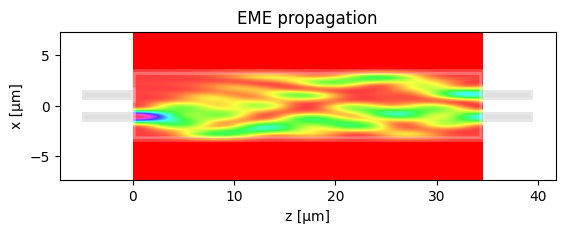

In [25]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/670 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9559
Total OUT power: 0.9001
Excess loss [dB] =  0.4570
------------------------
Power over OUTs:  ['0.4473', '0.4528']
Ratio over OUTs ['0.4969', '0.5031']


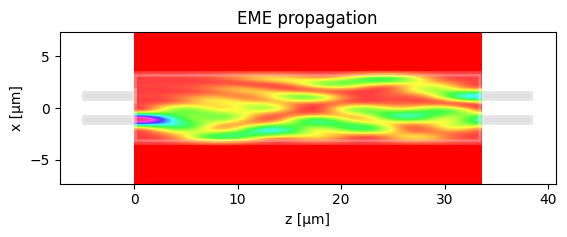

In [26]:
mmi_Width = 6.6 # Student. Body width

dy = 0.06
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -1  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [27]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.8 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.0359860725655  µm


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.8000
------------------------
Total power IN coupled 0.9949
Total OUT power: 0.9896
Excess loss [dB] =  0.0454
------------------------
Power over OUTs:  ['0.5053', '0.4843']
Ratio over OUTs ['0.5106', '0.4894']


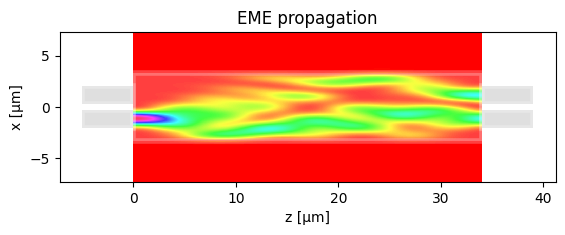

In [110]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.06

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [28]:
# Goal: 1 input, 4 outputs, ideally ~25% power in each output
# Less than 0.1 dB excess loss

# Define geometry
mmi_Width = 12.0      # wider than the 2x2 MMI to fit 4 outputs
wg_width = 0.95        # input/output waveguide width

m = MMI_EME()

m.MMI_width = mmi_Width
m.wg_width_dw = wg_width
m.MMI_num_modes = 30  # more modes because the MMI body is wider


In [29]:
# Compute MMI modes
m.find_all_modes()

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


In [30]:
# Calculate L_pi
L_pi = m.get_L_pi()
print("L_pi =", L_pi, "um")

L_pi = 219.13931544086205 um


In [31]:
# Configure 1x4 MMI

m.n_IN = 1
m.n_OUT = 4

# Input centered
m.IN_WVG_positions = mmi_Width * np.array([0])

# Four outputs symmetrically placed
m.OUT_WVG_positions = mmi_Width * np.array([-3/8, -1/8, 1/8, 3/8])

# First theoretical guess for 1x4 MMI length
m.L_MMI = (3/16) * L_pi

# Small length correction
m.dL_MMI = 0

print("L_MMI =", m.L_MMI, "um")
print("Input positions =", m.IN_WVG_positions)
print("Output positions =", m.OUT_WVG_positions)

L_MMI = 41.08862164516164 um
Input positions = [0.]
Output positions = [-4.5 -1.5  1.5  4.5]


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/822 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.9500
------------------------
Total power IN coupled 0.9982
Total OUT power: 0.9638
Excess loss [dB] =  0.1603
------------------------
Power over OUTs:  ['0.2345', '0.2474', '0.2475', '0.2344']
Ratio over OUTs ['0.2433', '0.2567', '0.2568', '0.2432']


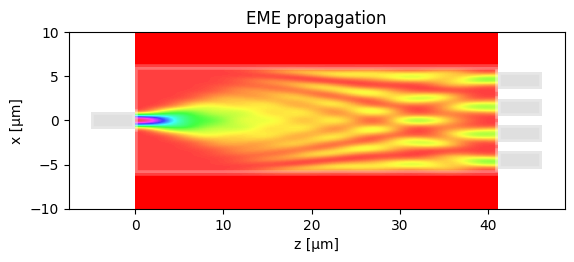

In [32]:
# Run propagation
m.propagation()

Total MMI length = 40.08862164519517 um


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/802 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 0.9500
------------------------
Total power IN coupled 0.9982
Total OUT power: 0.9780
Excess loss [dB] =  0.0965
------------------------
Power over OUTs:  ['0.2386', '0.2505', '0.2505', '0.2385']
Ratio over OUTs ['0.2439', '0.2561', '0.2562', '0.2438']


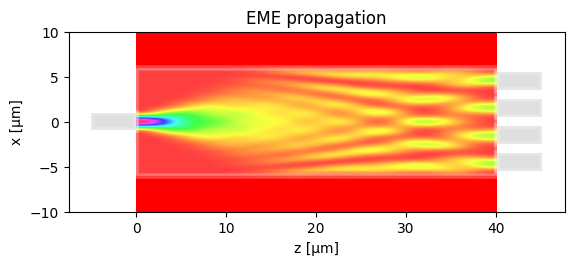

In [21]:
# Manual optimization: length tuning

m.n_IN = 1
m.n_OUT = 4

m.IN_WVG_positions = mmi_Width * np.array([0])
m.OUT_WVG_positions = mmi_Width * np.array([-3/8, -1/8, 1/8, 3/8])

m.L_MMI = (3/16) * L_pi

# Try values such as -3, -2, -1, -0.5, 0, 0.5, 1, 2, 3
m.dL_MMI = -1.0

print("Total MMI length =", m.L_MMI + m.dL_MMI, "um")

m.propagation()

Output positions = [-4.3 -1.3  1.3  4.3]
Total MMI length = 40.08862164516164 um


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/802 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 0.9500
------------------------
Total power IN coupled 0.9982
Total OUT power: 0.8695
Excess loss [dB] =  0.6073
------------------------
Power over OUTs:  ['0.2037', '0.2310', '0.2311', '0.2037']
Ratio over OUTs ['0.2343', '0.2657', '0.2657', '0.2343']


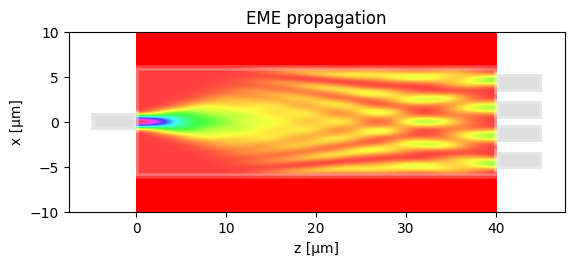

In [33]:
# Manual optimization: output position tuning

dy = 0.2  # try 0, 0.1, 0.2, 0.3, -0.1, etc.

m.n_IN = 1
m.n_OUT = 4

m.IN_WVG_positions = mmi_Width * np.array([0])

# Move external outputs slightly inward/outward
m.OUT_WVG_positions = mmi_Width * np.array([-3/8, -1/8, 1/8, 3/8]) + np.array([dy, dy, -dy, -dy])

m.L_MMI = (3/16) * L_pi
m.dL_MMI = -1.0

print("Output positions =", m.OUT_WVG_positions)
print("Total MMI length =", m.L_MMI + m.dL_MMI, "um")

m.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

2026-05-02 00:08:06.154 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

2026-05-02 00:08:12.506 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_266d67620f0948f9.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

...

2026-05-02 00:09:44.264 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_8e0bd02e52bb6fea.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

2026-05-02 00:09:51.264 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_cbd4017b74156e86.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

2026-05-02 00:09:58.035 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_186b33d829047bed.npz.


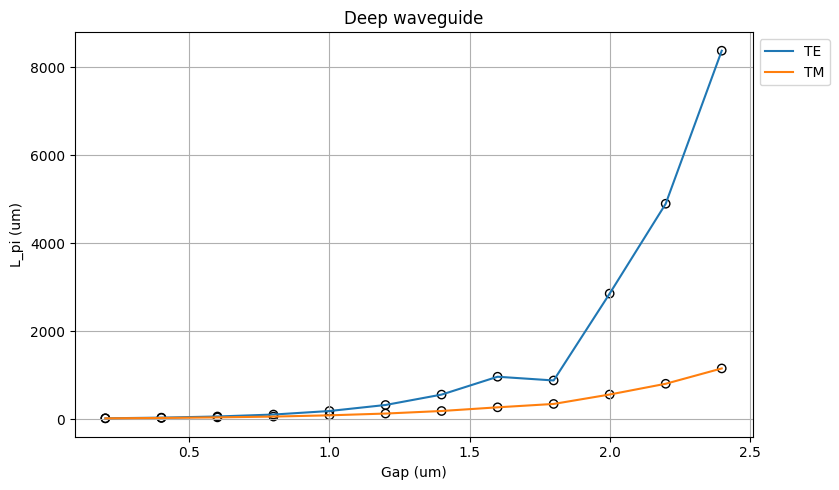

In [34]:
gap_to_simulate = np.arange(0.2, 2.4 + 0.001, 0.2)

L_pi_TE = []
L_pi_TM = []

for gap in gap_to_simulate:

    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=1.55, # Wavelength to simulate
        core_width=(1.0, 1.0), # Waveguide width
        gap=gap,
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=300 * nm, # Waveguide height 
        num_modes=4, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )

    deep_neff = deep_dcoupler_cs.n_eff

    L_pi_TE.append(0.5 * 1.55 / abs(deep_neff[0].real - deep_neff[1].real))
    L_pi_TM.append(0.5 * 1.55 / abs(deep_neff[2].real - deep_neff[3].real))


# STUDENT Plot goes here

plt.figure(figsize=(10, 5))
plt.scatter(gap_to_simulate, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(gap_to_simulate, L_pi_TE, label='TE')
plt.scatter(gap_to_simulate, L_pi_TM, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(gap_to_simulate, L_pi_TM, label='TM')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.title("Deep waveguide")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

00:17:49 CEST WARNING: Mode field at frequency index 0, mode index 3 does not   
              decay at the plane boundaries.                                    

2026-05-02 00:17:49.862 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_8c8eb63846dcafc2.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

00:17:59 CEST WARNING: Mode field at frequency index 0, mode index 3 does not   
              decay at the plane boundaries.                                    

...

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

00:18:53 CEST WARNING: Mode field at frequency index 0, mode index 3 does not   
              decay at the plane boundaries.                                    

2026-05-02 00:18:53.773 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_67ddc147ab8e16ec.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

2026-05-02 00:19:07.664 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_295e702940328765.npz.


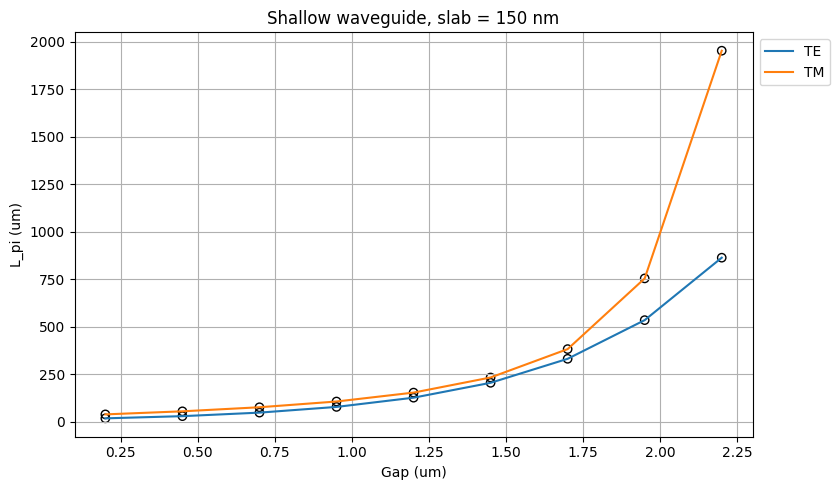

In [35]:
gap_to_simulate = np.arange(0.2, 2.4 + 0.001, 0.25)

L_pi_TE = []
L_pi_TM = []

for gap in gap_to_simulate:

    shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=1.55, # Wavelength to simulate
        core_width=(1.0, 1.0), # Waveguide width
        gap=gap,
        slab_thickness=150 * nm, # Shallow waveguide
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=300 * nm, # Waveguide height 
        num_modes=4, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )

    shallow_neff = shallow_dcoupler_cs.n_eff

    L_pi_TE.append(0.5 * 1.55 / abs(shallow_neff[0].real - shallow_neff[1].real))
    L_pi_TM.append(0.5 * 1.55 / abs(shallow_neff[2].real - shallow_neff[3].real))


# STUDENT Plot goes here

plt.figure(figsize=(10, 5))
plt.scatter(gap_to_simulate, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(gap_to_simulate, L_pi_TE, label='TE')
plt.scatter(gap_to_simulate, L_pi_TM, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(gap_to_simulate, L_pi_TM, label='TM')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.title("Shallow waveguide, slab = 150 nm")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### E2. Directional coupler wavelength dependence

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

2026-05-02 00:22:06.793 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_d7fb4453216b17d7.npz.


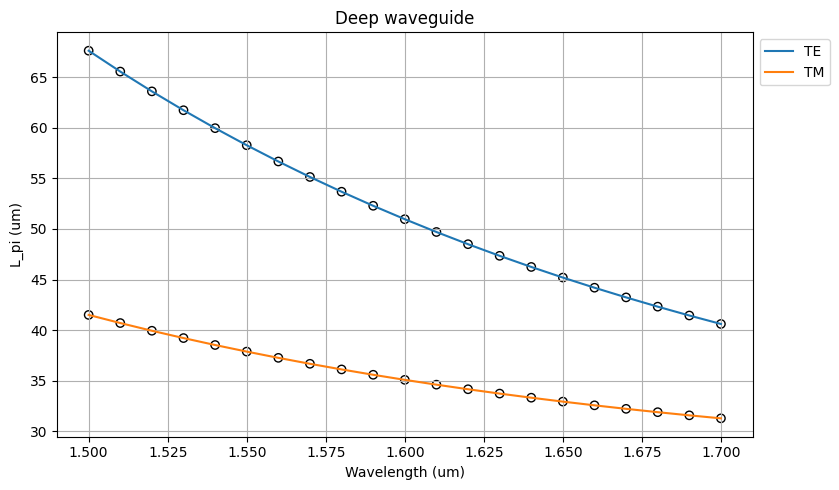

In [36]:
wavelength = np.arange(1.5, 1.7 + 0.001, 0.01) # STUDENT code goes here

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_neff = np.array(deep_dcoupler_cs.n_eff)

if deep_neff.shape[0] == len(wavelength):
    L_pi_TE = 0.5 * wavelength / np.abs(deep_neff[:, 0].real - deep_neff[:, 1].real)
    L_pi_TM = 0.5 * wavelength / np.abs(deep_neff[:, 2].real - deep_neff[:, 3].real)
else:
    L_pi_TE = 0.5 * wavelength / np.abs(deep_neff[0, :].real - deep_neff[1, :].real)
    L_pi_TM = 0.5 * wavelength / np.abs(deep_neff[2, :].real - deep_neff[3, :].real)

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(wavelength, L_pi_TE, label='TE')
plt.scatter(wavelength, L_pi_TM, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(wavelength, L_pi_TM, label='TM')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi (um)")
plt.title("Deep waveguide")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

00:31:27 CEST WARNING: Mode field at frequency index 0, mode index 2 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 1, mode index 2 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 2, mode index 2 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 3, mode index 2 does not   
              decay at the plane boundaries.                                    

...

              WARNING: Mode field at frequency index 17, mode index 2 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 18, mode index 2 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 19, mode index 2 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 20, mode index 2 does not  
              decay at the plane boundaries.                                    

2026-05-02 00:31:29.071 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_8f04dc623f0a74d0.npz.


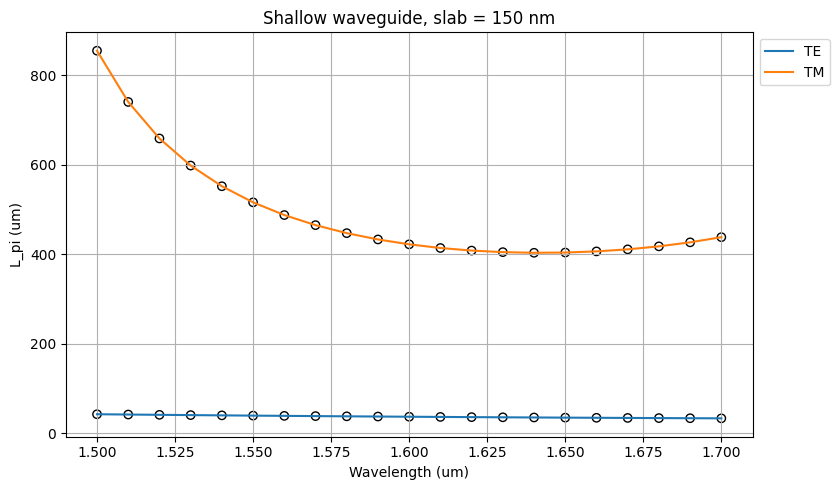

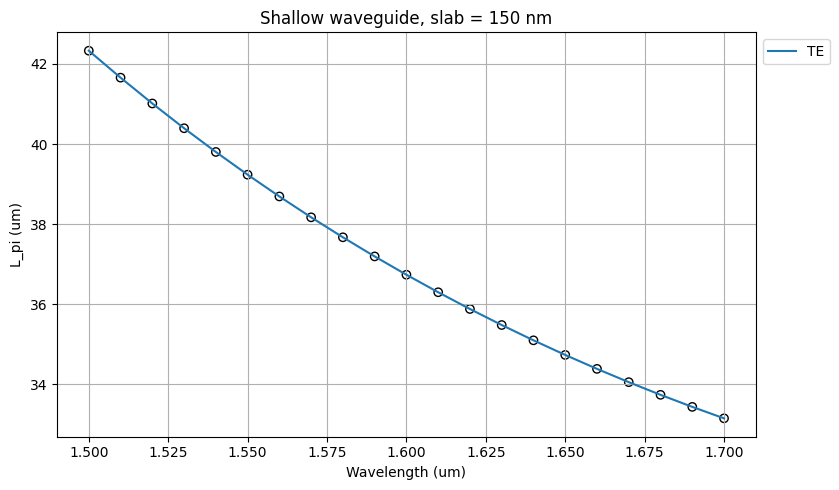

In [37]:
wavelength = np.arange(1.5, 1.7 + 0.001, 0.01) # STUDENT code goes here

shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=150 * nm, # Shallow waveguide
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

shallow_neff = np.array(shallow_dcoupler_cs.n_eff)

if shallow_neff.shape[0] == len(wavelength):
    L_pi_TE = 0.5 * wavelength / np.abs(shallow_neff[:, 0].real - shallow_neff[:, 1].real)
    L_pi_TM = 0.5 * wavelength / np.abs(shallow_neff[:, 2].real - shallow_neff[:, 3].real)
else:
    L_pi_TE = 0.5 * wavelength / np.abs(shallow_neff[0, :].real - shallow_neff[1, :].real)
    L_pi_TM = 0.5 * wavelength / np.abs(shallow_neff[2, :].real - shallow_neff[3, :].real)

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(wavelength, L_pi_TE, label='TE')
plt.scatter(wavelength, L_pi_TM, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(wavelength, L_pi_TM, label='TM')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi (um)")
plt.title("Shallow waveguide, slab = 150 nm")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(wavelength, L_pi_TE, label='TE')

plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi (um)")
plt.title("Shallow waveguide, slab = 150 nm")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### E3. MMI coupler wavelength dependence

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

00:32:01 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

2026-05-02 00:32:01.203 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_9a2f1ddbafc80a93.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

00:32:27 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

...

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

00:38:22 CEST WARNING: Mode field at frequency index 0, mode index 12 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 13 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

2026-05-02 00:38:22.877 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_0a2ea4e6cad70fbb.npz.


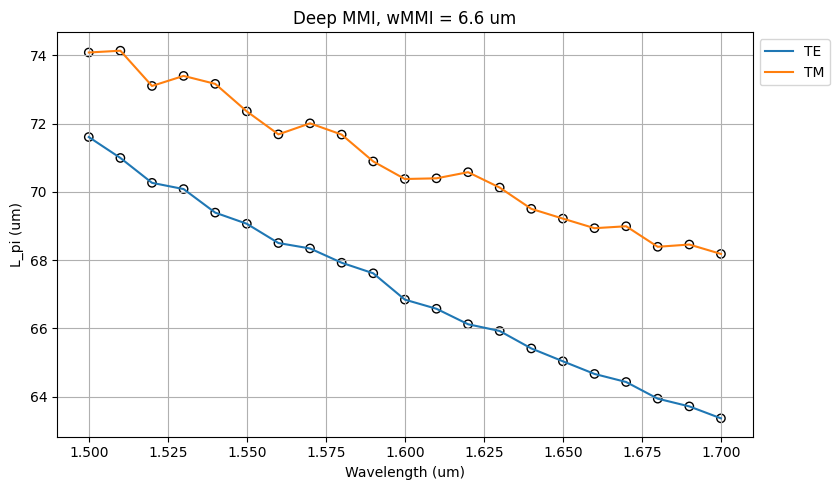

In [38]:
mmi_body_w = 6.6 
lambda_c = np.arange(1.5, 1.7 + 0.001, 0.01) # STUDENT code goes here.

L_pi_TE = []
L_pi_TM = []

for wavelength in lambda_c:

    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=wavelength, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    d_n_eff_TE = mmi_body_waveguide.n_eff[0].real - mmi_body_waveguide.n_eff[1].real

    fr_tm=mmi_body_waveguide.fraction_tm
    modes_tm_mmi = []
 
    for i, fr in enumerate(fr_tm):
        if fr > 0.5:
            modes_tm_mmi.append(i)

    # Nos quedamos con los dos primeros modos TM encontrados
    tm0 = modes_tm_mmi[0]
    tm1 = modes_tm_mmi[1]

    d_n_eff_TM = mmi_body_waveguide.n_eff[tm0].real - mmi_body_waveguide.n_eff[tm1].real
    

    L_pi_TE.append(0.5 * wavelength / abs(d_n_eff_TE)) # STUDENT code goes here
    L_pi_TM.append(0.5 * wavelength / abs(d_n_eff_TM))

# STUDENT plot here.


plt.figure(figsize=(10, 5))
plt.scatter(lambda_c, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(lambda_c, L_pi_TE, label='TE')
plt.scatter(lambda_c, L_pi_TM, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(lambda_c, L_pi_TM, label='TM')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi (um)")
plt.title("Deep MMI, wMMI = 6.6 um")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

00:38:34 CEST WARNING: Mode field at frequency index 0, mode index 9 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 12 does not  
              decay at the plane boundaries.                                    

2026-05-02 00:38:34.726 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_c26c25376372bde5.npz.


...

00:45:14 CEST WARNING: Mode field at frequency index 0, mode index 8 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 9 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 13 does not  
              decay at the plane boundaries.                                    

2026-05-02 00:45:14.743 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_3fb954140d259c7a.npz.


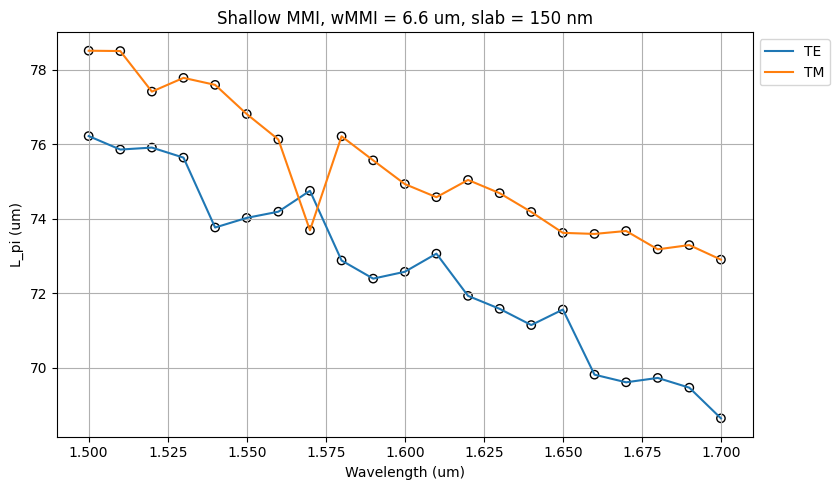

In [39]:
mmi_body_w = 6.6 
lambda_c = np.arange(1.5, 1.7 + 0.001, 0.01) # STUDENT code goes here.

L_pi_TE = []
L_pi_TM = []

for wavelength in lambda_c:

    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=150 * nm, # Shallow waveguide
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=wavelength, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    d_n_eff_TE = mmi_body_waveguide.n_eff[0].real - mmi_body_waveguide.n_eff[1].real

    fr_tm=mmi_body_waveguide.fraction_tm
    modes_tm_mmi = []
 
    for i, fr in enumerate(fr_tm):
        if fr > 0.5:
            modes_tm_mmi.append(i)

    # Nos quedamos con los dos primeros modos TM encontrados
    tm0 = modes_tm_mmi[0]
    tm1 = modes_tm_mmi[1]

    d_n_eff_TM = mmi_body_waveguide.n_eff[tm0].real - mmi_body_waveguide.n_eff[tm1].real

    L_pi_TE.append(0.5 * wavelength / abs(d_n_eff_TE)) # STUDENT code goes here
    L_pi_TM.append(0.5 * wavelength / abs(d_n_eff_TM))

# STUDENT plot here.

plt.figure(figsize=(10, 5))
plt.scatter(lambda_c, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(lambda_c, L_pi_TE, label='TE')
plt.scatter(lambda_c, L_pi_TM, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(lambda_c, L_pi_TM, label='TM')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi (um)")
plt.title("Shallow MMI, wMMI = 6.6 um, slab = 150 nm")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### E4. MMI coupler body width dependence

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

00:47:18 CEST WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 12 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 13 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

...

2026-05-02 00:51:00.027 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_09f64d33f8d29b19.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

2026-05-02 00:51:14.373 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_cb827f9f108742e4.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

2026-05-02 00:51:31.668 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_0715b5214f4328e7.npz.


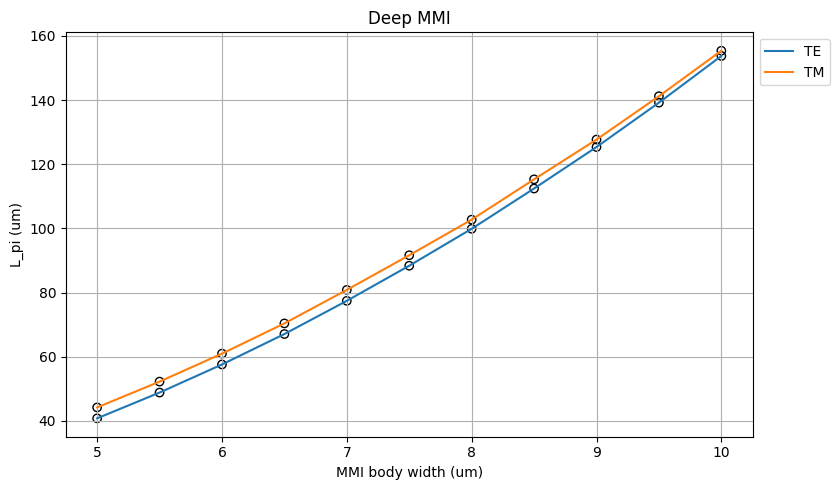

In [40]:
lambda_c = 1.55

mmi_body_w = np.arange(5.0, 10.0 + 0.001, 0.5) # STUDENT. You can manually change the body width

L_pi_TE = []
L_pi_TM = []

for width in mmi_body_w:

    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=width, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    d_n_eff_TE = mmi_body_waveguide.n_eff[0].real - mmi_body_waveguide.n_eff[1].real


    fr_tm=mmi_body_waveguide.fraction_tm
    modes_tm_mmi = []
 
    for i, fr in enumerate(fr_tm):
        if fr > 0.5:
            modes_tm_mmi.append(i)

    # Nos quedamos con los dos primeros modos TM encontrados
    tm0 = modes_tm_mmi[0]
    tm1 = modes_tm_mmi[1]

    d_n_eff_TM = mmi_body_waveguide.n_eff[tm0].real - mmi_body_waveguide.n_eff[tm1].real


    L_pi_TE.append(0.5 * lambda_c / abs(d_n_eff_TE)) # STUDENT code goes here
    L_pi_TM.append(0.5 * lambda_c / abs(d_n_eff_TM))

# STUDENT plot here.

plt.figure(figsize=(10, 5))
plt.scatter(mmi_body_w, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(mmi_body_w, L_pi_TE, label='TE')
plt.scatter(mmi_body_w, L_pi_TM, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(mmi_body_w, L_pi_TM, label='TM')
plt.xlabel("MMI body width (um)")
plt.ylabel("L_pi (um)")
plt.title("Deep MMI")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

00:51:42 CEST WARNING: Mode field at frequency index 0, mode index 8 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 9 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 13 does not  
              decay at the plane boundaries.                                    

...

00:53:57 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

2026-05-02 00:53:57.798 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_4e080f8573a04258.npz.


/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/marsama2/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d

00:54:15 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

2026-05-02 00:54:15.188 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_17e36e7035c1827e.npz.


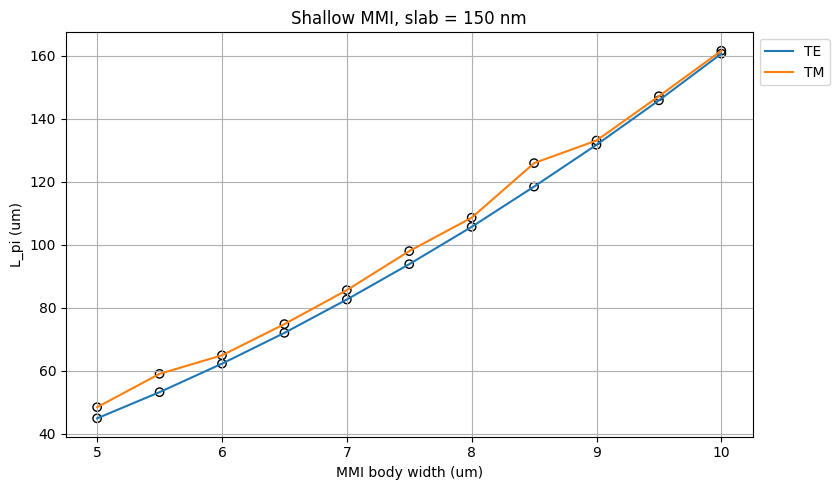

In [41]:
lambda_c = 1.55

mmi_body_w = np.arange(5.0, 10.0 + 0.001, 0.5) # STUDENT. You can manually change the body width

L_pi_TE = []
L_pi_TM = []

for width in mmi_body_w:

    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=width, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=150 * nm, # Shallow waveguide
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    d_n_eff_TE = mmi_body_waveguide.n_eff[0].real - mmi_body_waveguide.n_eff[1].real

    fr_tm=mmi_body_waveguide.fraction_tm
    modes_tm_mmi = []
 
    for i, fr in enumerate(fr_tm):
        if fr > 0.5:
            modes_tm_mmi.append(i)

    # Nos quedamos con los dos primeros modos TM encontrados
    tm0 = modes_tm_mmi[0]
    tm1 = modes_tm_mmi[1]

    d_n_eff_TM = mmi_body_waveguide.n_eff[tm0].real - mmi_body_waveguide.n_eff[tm1].real


    L_pi_TE.append(0.5 * lambda_c / abs(d_n_eff_TE)) # STUDENT code goes here
    L_pi_TM.append(0.5 * lambda_c / abs(d_n_eff_TM))

# STUDENT plot here.

plt.figure(figsize=(10, 5))
plt.scatter(mmi_body_w, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(mmi_body_w, L_pi_TE, label='TE')
plt.scatter(mmi_body_w, L_pi_TM, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(mmi_body_w, L_pi_TM, label='TM')
plt.xlabel("MMI body width (um)")
plt.ylabel("L_pi (um)")
plt.title("Shallow MMI, slab = 150 nm")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points